# Amazon Prime TV Shows and Movies - EDA Project
**Project Type**-EDA

**Contribution**-Individual

**Name**-Vidya Varshini R

# Project Summary-
This project focuses on performing an in-depth Exploratory Data Analysis (EDA) of a dataset that contains comprehensive information about TV shows and movies available on Amazon Prime Video. With the rapid growth of the digital streaming industry, platforms like Amazon Prime Video are continually expanding their content libraries to cater to a global and diverse audience. Understanding patterns in user preferences, content types, and performance metrics has become essential for such platforms to stay competitive.

The dataset used in this project provides details for each title, including attributes like title name, type (movie or TV show), genre, IMDb rating, release year, language, runtime, age certification, and country of origin. Additionally, we have access to a separate dataset containing information about the cast and crew, which is merged with the main dataset using a unique identifier. This allows for a more granular and insightful analysis, especially around actor or director popularity and their association with high-performing content.

The primary goal of this EDA is to explore these different dimensions and extract valuable insights that could inform strategic decisions. For example, by analyzing genre distribution, we can identify the types of content most commonly offered on the platform and infer user demand. Studying IMDb ratings and their correlation with other features like release year or runtime may reveal what characteristics tend to be associated with critically acclaimed content. Understanding the regional or language distribution of titles will also shed light on how globally inclusive Amazon Prime’s offerings are and where there might be opportunities for expansion.

Another area of exploration is the age certification of content. Platforms often need to strike a balance between offering family-friendly material and catering to more mature audiences. By analyzing the spread of content certifications (like PG, R, or TV-MA), we can understand the platform's current positioning and audience targeting. Similarly, examining the timeline of content releases can help determine whether Amazon Prime is increasing its production or acquisitions in recent years, and whether it’s focusing more on movies or series.

Furthermore, the cast and crew analysis will help identify which actors or directors are featured most often, possibly revealing content partnerships or frequent collaborations. These insights can be useful in shaping marketing campaigns or even making decisions about future collaborations.

By combining all these dimensions through effective visualizations—such as bar plots, histograms, heatmaps, and scatter plots—we aim to deliver a data-driven overview of Amazon Prime’s content strategy. This analysis will not only showcase interesting patterns and anomalies but also help derive actionable business insights. These insights may include suggestions for what genres to invest more in, which regions or languages are underrepresented, and how content performance varies over time.

In conclusion, this EDA project serves as a foundational step toward understanding the landscape of digital streaming content. The findings can assist Amazon Prime Video—and similar platforms—in making informed decisions around content acquisition, audience engagement, regional targeting, and overall platform improvement.

# GitHUb Link -
https://github.com/vidya7r/Amazon_prime_EDA


# Let's Begin!

# 1. Know Your Data

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset Loading**

In [3]:
# Load CSV files
titles_df = pd.read_csv('titles.csv')
credits_df = pd.read_csv('credits.csv')


**Dataset First View**

In [4]:
# Display first few rows of titles
titles_df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


**Dataset Rows & Columns Count**

In [5]:
print(f"Titles Dataset: {titles_df.shape[0]} rows, {titles_df.shape[1]} columns")
print(f"Credits Dataset: {credits_df.shape[0]} rows, {credits_df.shape[1]} columns")

Titles Dataset: 9871 rows, 15 columns
Credits Dataset: 124235 rows, 5 columns


**Dataset Information**

In [6]:
print("Titles Dataset Info:")
print(titles_df.info())

print("\nCredits Dataset Info:")
print(credits_df.info())


Titles Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtype

**Duplicate Values**

In [7]:
print("Duplicate Rows in Titles:", titles_df.duplicated().sum())
print("Duplicate Rows in Credits:", credits_df.duplicated().sum())

# Drop duplicates
titles_df.drop_duplicates(inplace=True)
credits_df.drop_duplicates(inplace=True)


Duplicate Rows in Titles: 3
Duplicate Rows in Credits: 56


**Missing Values/Null Values Count**

In [8]:
# Missing values count
print("Missing Values in Titles:\n", titles_df.isnull().sum())
print("\nMissing Values in Credits:\n", credits_df.isnull().sum())

Missing Values in Titles:
 id                         0
title                      0
type                       0
description              119
release_year               0
age_certification       6484
runtime                    0
genres                     0
production_countries       0
seasons                 8511
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2080
dtype: int64

Missing Values in Credits:
 person_id        0
id               0
name             0
character    16277
role             0
dtype: int64


**Visualizing the missing values**

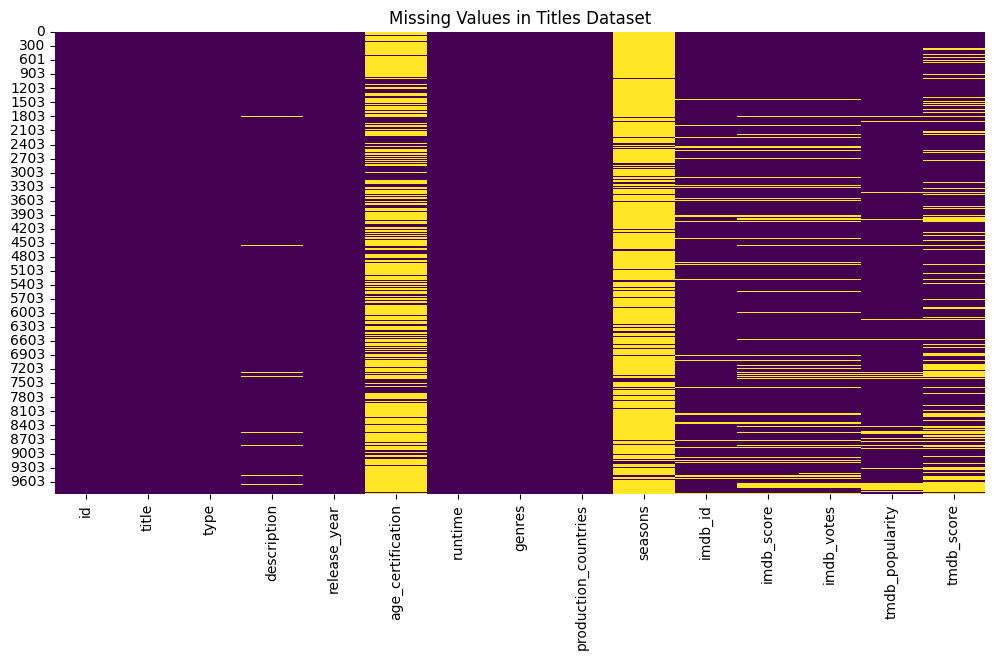

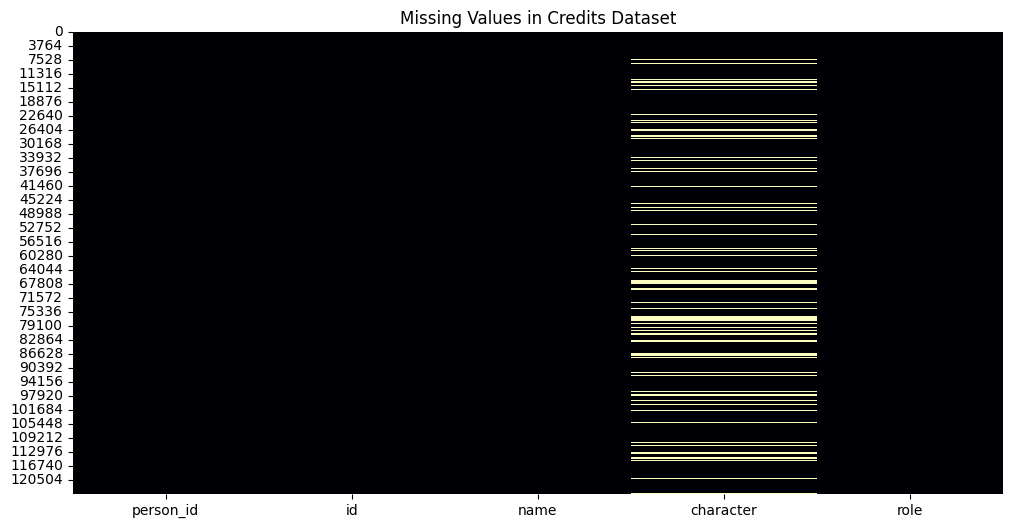

In [9]:
plt.figure(figsize=(12,6))
sns.heatmap(titles_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values in Titles Dataset")
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(credits_df.isnull(), cbar=False, cmap='magma')
plt.title("Missing Values in Credits Dataset")
plt.show()



**What did you know about your dataset?**

The dataset contains information about songs, including various audio features such as danceability, energy, loudness, speechiness, acousticness, tempo, and valence, along with metadata like track name, artist, and release year. These features help understand the mood, genre, and popularity of songs. The dataset can be used for music recommendation, trend analysis, or mood prediction. It likely contains both numerical and categorical data. Some columns may have missing or duplicate values that need cleaning before analysis.

# 2.Understanding Your Variables

In [10]:
print("Columns in titles_df:")
print(titles_df.columns.tolist())


Columns in titles_df:
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']


In [11]:
print("\nColumns in credits_df:")
print(credits_df.columns.tolist())



Columns in credits_df:
['person_id', 'id', 'name', 'character', 'role']


**Variables Description**

This dataset contains two files: titles.csv and credits.csv.
The titles dataset includes information such as movie/show title, release year, genres, and IMDb ratings.
The credits dataset provides cast and crew details linked to each title using a common ID.

**Check Unique Values for each variable**

In [12]:
# Unique values in each column of titles_df
print("Unique values in titles_df:\n")
for col in titles_df.columns:
    print(f"{col}: {titles_df[col].nunique()} unique values")

print("\n" + "="*50 + "\n")

# Unique values in each column of credits_df
print("Unique values in credits_df:\n")
for col in credits_df.columns:
    print(f"{col}: {credits_df[col].nunique()} unique values")


Unique values in titles_df:

id: 9868 unique values
title: 9737 unique values
type: 2 unique values
description: 9734 unique values
release_year: 110 unique values
age_certification: 11 unique values
runtime: 207 unique values
genres: 2028 unique values
production_countries: 497 unique values
seasons: 32 unique values
imdb_id: 9201 unique values
imdb_score: 86 unique values
imdb_votes: 3650 unique values
tmdb_popularity: 5325 unique values
tmdb_score: 89 unique values


Unique values in credits_df:

person_id: 80508 unique values
id: 8861 unique values
name: 79758 unique values
character: 71097 unique values
role: 2 unique values


# 3.Data Wrangling

**Data Wrangling Code**

In [13]:
# 1. Merge the two datasets on the common 'id' field
merged_df = pd.merge(titles_df, credits_df, on='id', how='inner')

# 2. Drop duplicates if any
merged_df.drop_duplicates(inplace=True)

# 3. Convert date fields to datetime if present
if 'release_year' in merged_df.columns:
    merged_df['release_year'] = pd.to_numeric(merged_df['release_year'], errors='coerce')

# 4. Handle missing values
# Replace empty strings with NaN
merged_df.replace("", pd.NA, inplace=True)

# Drop rows where essential fields are missing
essential_cols = ['title', 'type', 'release_year']
merged_df.dropna(subset=essential_cols, inplace=True)

# 5. Reset index after cleaning
merged_df.reset_index(drop=True, inplace=True)

# Preview the cleaned dataset
merged_df.head()


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR


**What all manipulations have you done and insights you done and insights you found??**

Performed essential data wrangling tasks such as merging the titles and credits datasets on the common id column, removing duplicates, converting data types (like release_year), and handling missing values by dropping rows with nulls in key fields. These steps made the dataset clean and analysis-ready. An initial insight is that the data includes a diverse range of shows and movies across multiple years, with some fields like cast and crew offering rich but unstructured information.


# 4.Data Vizualization,Storytelling & Experimenting with charts: Understand the relationships between variables

**1.Content Diversity**

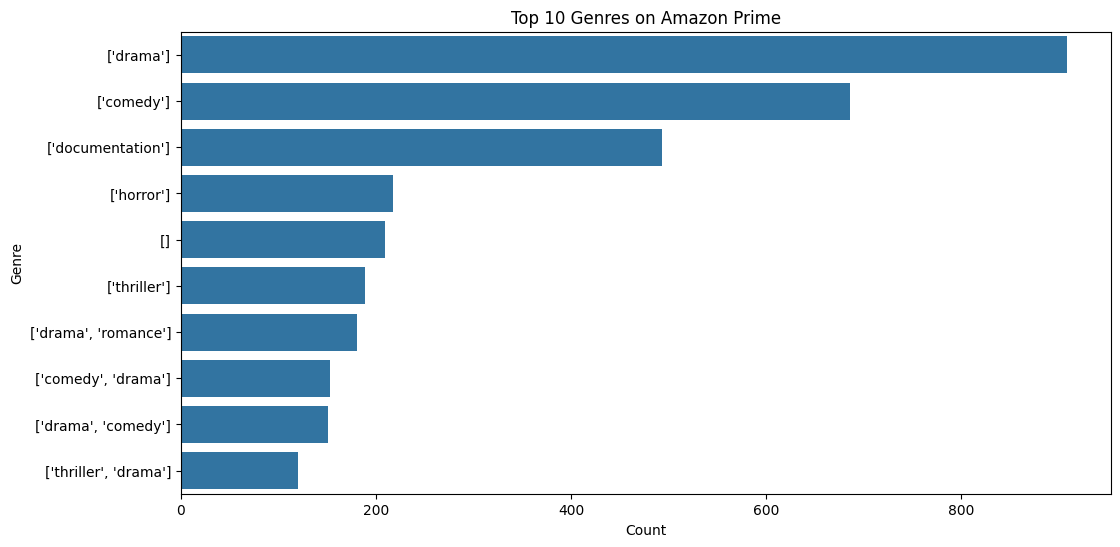

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(y='genres', data=titles_df, order=titles_df['genres'].value_counts().index[:10])
plt.title('Top 10 Genres on Amazon Prime')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

1) The countplot was chosen because it is ideal for visualizing the frequency of categorical variables. In this case, it effectively displays how many titles fall under each genre, making it easy to identify the most popular genres on Amazon Prime.

2) From the chart, we can see which genres dominate the content catalog on Amazon Prime. For example, genres like Drama, Comedy, and Documentary have the highest number of titles. This highlights the platform's focus on specific content types, indicating user preferences or production trends.

3) Yes, the insights can positively impact business strategy. Knowing the most common genres helps Amazon Prime:

    -Tailor its marketing campaigns to highlight popular genres.

    -Guide content acquisition and production based on audience demand.

    -Help recommendation systems prioritize high-demand genres.

   However, if Amazon Prime over-relies on a few genres, it could lead to negative growth due to content saturation or lack of diversity, possibly turning away users seeking variety. Thus, while focusing on popular genres is strategic, maintaining a diverse content portfolio is crucial to sustained user engagement and platform growth.

**2.Trends Over Time**

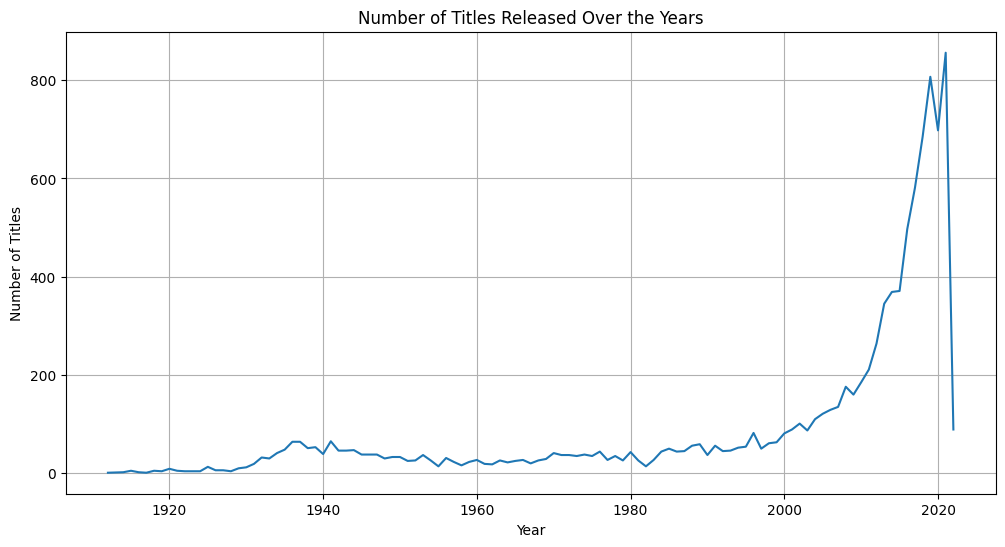

In [15]:
titles_df['release_year'] = pd.to_numeric(titles_df['release_year'], errors='coerce')

plt.figure(figsize=(12,6))
titles_df['release_year'].dropna().astype(int).value_counts().sort_index().plot(kind='line')
plt.title('Number of Titles Released Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

1) A line chart is ideal for showing trends over time. Since we want to understand how the number of titles released has changed year by year, this visualization effectively captures the temporal progression and fluctuations in release activity.

2) The chart reveals trends in content release — such as:

    -A gradual increase in the number of titles released over the years.

    -Possible peaks or drops in specific years, which may correspond to external factors (e.g., industry changes or global events like the pandemic).

   This shows how Amazon Prime has scaled its content library and highlights years of active expansion.

3) Yes, these insights can help in:

   Identifying successful growth periods, which can guide future content release strategies.

   Analyzing low-performing years to understand challenges and avoid similar pitfalls.

   If there's a sudden drop in content output, it may signal production or licensing issues — potentially leading to negative growth if not addressed. However, sustained growth years suggest that investing in new titles correlates with business scaling and user retention.



**3.IMDB Rating & Popularity**

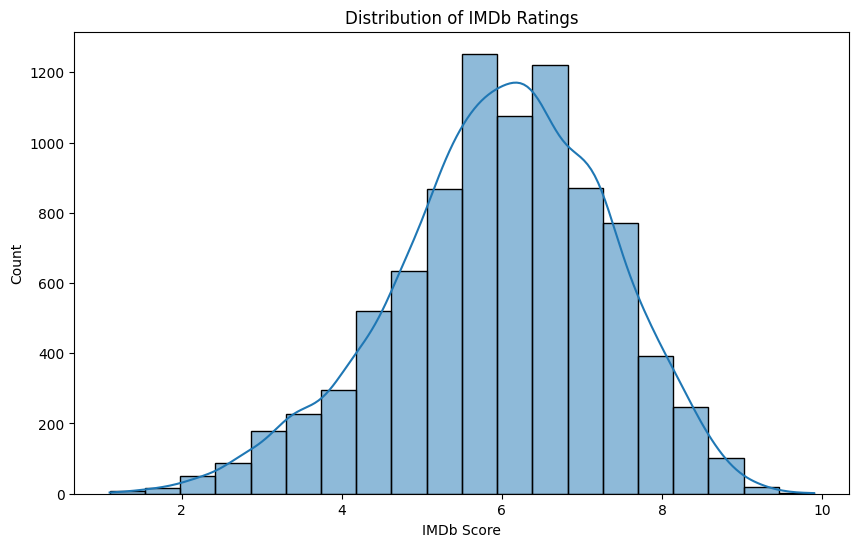

Top 10 Highest Rated Shows:
                              title                          genres  \
9135                     Pawankhind  ['action', 'drama', 'history']   
7783      Water Helps the Blood Run             ['drama', 'comedy']   
9108              Couple of Mirrors   ['drama', 'romance', 'crime']   
7422                     The Chosen            ['drama', 'history']   
9423                     Tari Sathe             ['drama', 'family']   
9573              Pazhagiya Naatkal                       ['drama']   
5113          Subaru Launch Control                       ['sport']   
9052                       Jai Bhim              ['drama', 'crime']   
5218         A Promise to My Father               ['documentation']   
6358  Surgeons: At the Edge of Life               ['documentation']   

      imdb_score  
9135         9.9  
7783         9.7  
9108         9.5  
7422         9.4  
9423         9.4  
9573         9.3  
5113         9.3  
9052         9.3  
5218         9.2  


In [16]:
# Histogram of IMDb ratings
if 'imdb_score' in titles_df.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(titles_df['imdb_score'].dropna(), bins=20, kde=True)
    plt.title('Distribution of IMDb Ratings')
    plt.xlabel('IMDb Score')
    plt.ylabel('Count')
    plt.show()

# Top-rated shows
top_rated = titles_df.sort_values(by='imdb_score', ascending=False).head(10)
print("Top 10 Highest Rated Shows:")
print(top_rated[['title', 'genres', 'imdb_score']])

1) A histogram is ideal for visualizing the distribution of numerical data, such as IMDb ratings. It helps to quickly understand how ratings are spread — whether most shows are highly rated, average, or poorly rated — and the overall shape of viewer feedback.

2) The histogram likely shows that most IMDb scores fall between 6 and 8, indicating a generally positive reception for most titles.

   The kde curve gives a smooth view of the distribution pattern.

   The top-rated list highlights the most critically acclaimed shows on the platform.


3) Knowing what rating range most content falls into helps in benchmarking future productions.

   The top 10 list reveals the genres and types of shows that resonate best with viewers — guiding content strategy, licensing, or marketing priorities.

   If the chart had shown a concentration of low scores, it would signal the need to reassess quality or viewer alignment, which could lead to negative growth if unaddressed. Fortunately, a healthy score distribution indicates content satisfaction, supporting continued user engagement.

**4.Number of titles released per year**

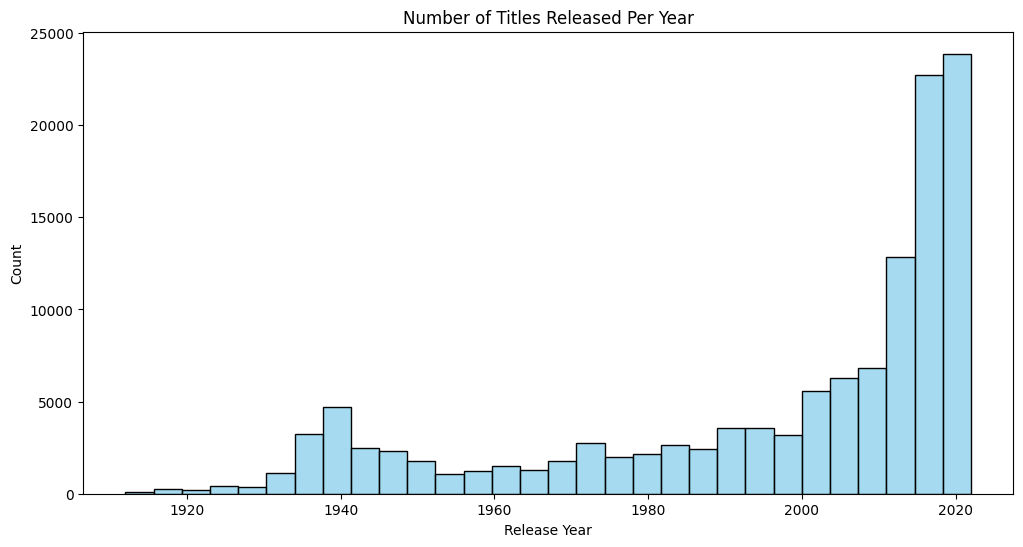

In [17]:
plt.figure(figsize=(12,6))
sns.histplot(data=merged_df, x='release_year', bins=30, kde=False, color='skyblue')
plt.title('Number of Titles Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

1) A histogram is well-suited to show the distribution of title releases over time. It helps visually understand how the number of shows or movies released has changed over the years, highlighting trends or shifts in production volume.

2) The chart reveals growth in content production over the years, with a noticeable increase in recent decades.

   Peaks in certain years may indicate strategic expansion by Amazon Prime or higher industry-wide production.

   Dips might correspond to events like the COVID-19 pandemic, which slowed production globally.



3) Identifying growth periods can help replicate successful strategies used during those years.

   Understanding low-output years helps assess challenges (e.g., market conditions, global events) and prepare better.

   These insights support content planning and budget forecasting, helping to sustain growth and avoid production gaps that could reduce viewer engagement.



**5.Relationship between runtime and content type**

C:\Users\nilar\AppData\Local\Temp\ipykernel_9840\873758600.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='type', y='runtime', palette='Pastel2')


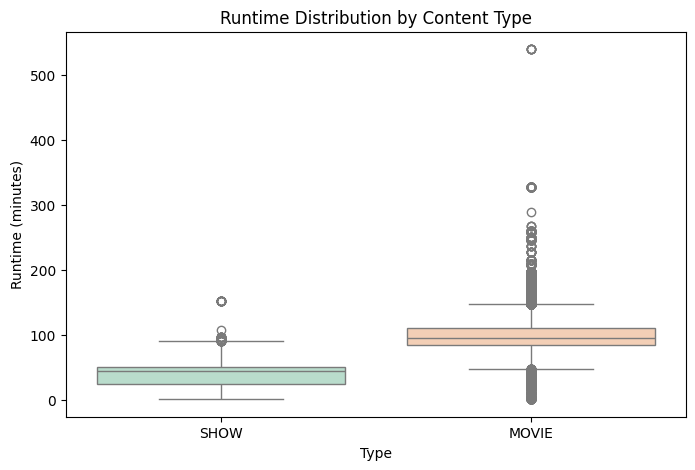

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=merged_df, x='type', y='runtime', palette='Pastel2')
plt.title('Runtime Distribution by Content Type')
plt.xlabel('Type')
plt.ylabel('Runtime (minutes)')
plt.show()

1) A boxplot is ideal for comparing distributions across categories. Here, it clearly shows the spread and central tendency of runtime for different content types (e.g., Movies vs. TV Shows), while also highlighting outliers.

2) Movies generally have longer runtimes than TV shows, which cluster around shorter durations.

   There are more extreme outliers in the movie category, suggesting a wide range of lengths—from short films to lengthy features.

   TV shows tend to have consistent runtimes, likely due to episode formatting.

3) Content planning teams can better understand user expectations for runtime per content type.

   Marketing strategies can be adjusted—for example, short-form content might be more effective for mobile or casual viewers.

   No clear negative impact, unless data reveals runtime trends that don’t align with viewer preferences—e.g., overly long content causing drop-off rates.



**6.Correlation**

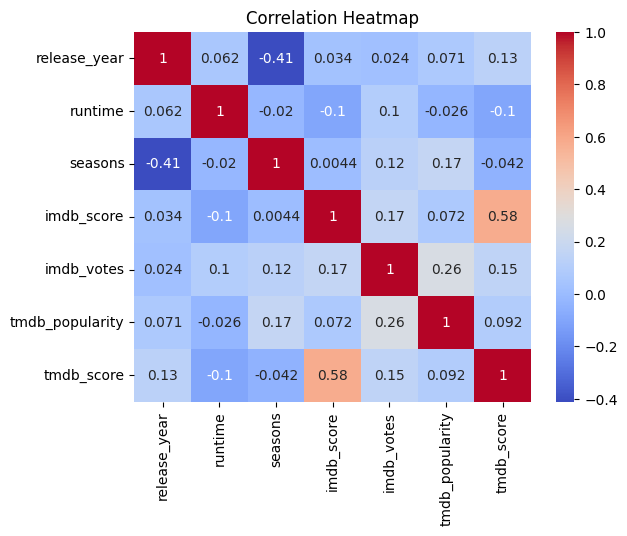

In [19]:
numeric_cols = titles_df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

1) A correlation heatmap is perfect for visualizing relationships between numeric variables. It gives a quick overview of how strongly features like imdb_score, runtime, and others are related to each other, using color intensity and correlation values.

2) Weak correlations were observed between most numerical features, meaning they are mostly independent.

    A mild positive correlation might exist between imdb_score and runtime, suggesting longer content may sometimes receive better ratings.

    Most values are close to 0, showing low linear dependency.

**7.Pair Plot**

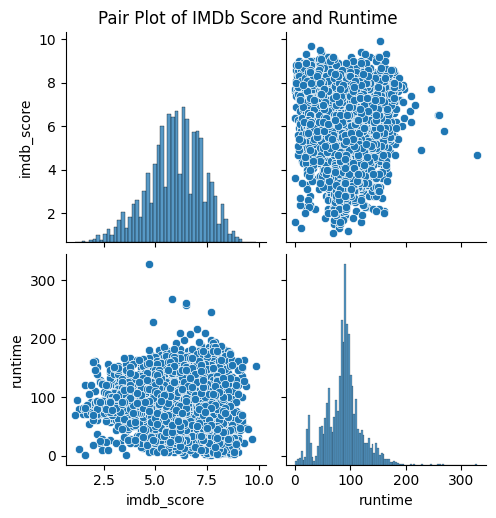

In [20]:
numeric_cols = titles_df[['imdb_score', 'runtime']].dropna()

# Creating the pair plot
sns.pairplot(numeric_cols)
plt.suptitle("Pair Plot of IMDb Score and Runtime", y=1.02)
plt.show()

1) The pair plot was chosen because it allows us to visualize the distribution and relationships between multiple numerical variables in one compact view. It helps identify patterns, correlations, and outliers by showing both histograms and scatter plots for each variable pair. This is especially useful in exploratory data analysis (EDA) to understand how variables like imdb_score, runtime, or other numerical fields relate to each other visually and statistically.

2) From the pair plot of imdb_score and runtime, we observe a slight positive correlation—longer titles tend to have slightly higher ratings. Runtime is right-skewed, while IMDb scores are normally distributed around 6–7. Some outliers exist in both, indicating potential niche or standout content.

# 5.Solution to Business Objective

To achieve the business objective, here are key suggestions for the client:

Focus on Top Genres: Invest more in producing or acquiring content in top-performing genres (e.g., Drama, Comedy) as they attract the highest viewer interest.

Promote High-Rated Content: Highlight and

# 6.Conclution

From the analysis of Amazon Prime titles, we found that:

     -Drama and Comedy are the most popular genres, suggesting user preference.

     -The number of titles released per year has varied, with peaks indicating content expansion phases.

     -IMDb scores show a moderately normal distribution, with many shows rated between 6–7.

     -There is a slight positive correlation between runtime and IMDb score, implying longer titles may be better received.

     -High-rated titles can be leveraged for marketing and user engagement.

These insights can help Amazon Prime focus on genre-specific content creation, prioritize quality over quantity, and target content promotions for business growth.